## Chaperones are concentrated within specific modules rather than distributed across the network.

In [10]:
# Imports & Utility Functions 
import pandas as pd
import numpy as np
import networkx as nx
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import pickle
import os

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# ------------------------------------------------------------------
# Participation coefficient & within-module z-score (unchanged, just cleaned)
# ------------------------------------------------------------------
def participation_coefficient(G: nx.Graph, communities: dict) -> dict:
    """PC_i = 1 - Σ (k_i,m / k_i)²"""
    comm_to_nodes = {}
    for node, comm in communities.items():
        comm_to_nodes.setdefault(comm, set()).add(node)
    pc = {}
    for node in G.nodes():
        k_i = G.degree(node)
        if k_i == 0:
            pc[node] = 0.0
            continue
        module_counts = {}
        for nbr in G.neighbors(node):
            module_counts[communities[nbr]] = module_counts.get(communities[nbr], 0) + 1
        sum_sq = sum((count / k_i)**2 for count in module_counts.values())
        pc[node] = 1.0 - sum_sq
    return pc

def within_module_z_score(G: nx.Graph, communities: dict) -> dict:
    """z_i = (k_i,m - mean_m) / std_m"""
    intra_degrees = {}
    for node in G.nodes():
        comm = communities[node]
        intra_deg = sum(1 for nbr in G.neighbors(node) if communities[nbr] == comm)
        intra_degrees[node] = intra_deg

    comm_to_values = {}
    for node, comm in communities.items():
        comm_to_values.setdefault(comm, []).append(intra_degrees[node])

    comm_stats = {}
    for comm, vals in comm_to_values.items():
        vals = np.array(vals)
        mean = vals.mean()
        std = vals.std(ddof=1) if len(vals) > 1 else 0.0
        comm_stats[comm] = (mean, std)

    z_scores = {}
    for node, comm in communities.items():
        k_im = intra_degrees[node]
        mean, std = comm_stats[comm]
        z_scores[node] = 0.0 if std == 0 else (k_im - mean) / std
    return z_scores

# ------------------------------------------------------------------
# New: Permutation test for mean clustering / closeness (your missing function)
# ------------------------------------------------------------------
def evaluate_chaperone_positions(
    G: nx.Graph,
    chaperone_nodes: set,
    metric: str = "clustering",
    n_random_sets: int = 500,
    seed: int = 42,
    show_progress: bool = True,
) -> tuple[float, float, float]:
    """Returns (obs_mean, rand_mean, p_value). Small p = unusually high metric."""
    if metric == "clustering":
        values = nx.clustering(G)
    elif metric == "closeness":
        values = nx.closeness_centrality(G)
    else:
        raise ValueError("metric must be 'clustering' or 'closeness'")

    obs_mean = np.mean([values.get(n, 0.0) for n in chaperone_nodes])

    all_nodes = list(G.nodes())
    n_chaps = len(chaperone_nodes)
    rng = np.random.default_rng(seed)
    rand_means = []
    for _ in tqdm(range(n_random_sets), desc=f"Sampling random {metric}", disable=not show_progress):
        rand_set = rng.choice(all_nodes, n_chaps, replace=False)
        rand_means.append(np.mean([values.get(n, 0.0) for n in rand_set]))

    mean_rand = np.mean(rand_means)
    p_value = (np.sum(np.array(rand_means) >= obs_mean) + 1) / (n_random_sets + 1)  # one-sided for "unusually high"
    return obs_mean, mean_rand, p_value

In [11]:
# Load Data & Build Graph 
DATA_PATH1 = "../../0-download-inputs/data-files/"
DATA_PATH2 = "../../18-finalize/processed-data/"

nodes_path = f"{DATA_PATH2}20260210-s288c-ANnnotated-Yeast-Interactome.pkl"
edges_path = f"{DATA_PATH1}The_Yeast_Interactome_edges.csv"

nodes_df = pd.read_pickle(nodes_path)
edges_df = pd.read_csv(edges_path)
edges_clean = edges_df[["source", "target"]].dropna().copy()

valid_nodes = set(nodes_df["node"])
edges_clean = edges_clean[
    edges_clean["source"].isin(valid_nodes) &
    edges_clean["target"].isin(valid_nodes) &
    (edges_clean["source"] != edges_clean["target"])
]

G_full = nx.from_pandas_edgelist(edges_clean, create_using=nx.Graph())
nx.set_node_attributes(G_full, nodes_df.set_index("node").to_dict("index"))

# Largest connected component
largest_cc = max(nx.connected_components(G_full), key=len)
G_lcc = G_full.subgraph(largest_cc).copy()

# Chaperones
all_chaperones = set()
for lst in nodes_df["interacting_chaperones"]:
    if isinstance(lst, (list, set, tuple)):
        all_chaperones.update(lst)

nodes_df["is_chaperone"] = nodes_df["node"].isin(all_chaperones)
chaperones = set(nodes_df.loc[nodes_df["is_chaperone"], "node"]).intersection(G_lcc.nodes())

print(f"Nodes in LCC: {G_lcc.number_of_nodes():,}")
print(f"Chaperones in LCC: {len(chaperones)}")

Nodes in LCC: 3,839
Chaperones in LCC: 65


In [12]:
# Community Detection (Clauset–Newman–Moore / fast-greedy algorithm, 2004) + k-core
greedy_comms = list(nx.algorithms.community.greedy_modularity_communities(G_lcc))
community_map = {}
for idx, comm in enumerate(greedy_comms):
    for node in comm:
        community_map[node] = idx

k_core_dict = nx.core_number(G_lcc)

print(f"Communities detected: {len(greedy_comms)}")
print(f"Top 5 community sizes: {[len(c) for c in greedy_comms[:5]]}")

# Save community map
save_dir = "../../18-finalize/processed-data/"
os.makedirs(save_dir, exist_ok=True)
with open(os.path.join(save_dir, "community_map.pkl"), "wb") as f:
    pickle.dump(community_map, f)
print("Saved community_map.pkl")

Communities detected: 30
Top 5 community sizes: [1060, 636, 520, 453, 331]
Saved community_map.pkl


In [13]:
# Participation Coefficient & Within-Module z-score 
pc_dict = participation_coefficient(G_lcc, community_map)
z_score_dict = within_module_z_score(G_lcc, community_map)

# All centralities you mentioned (pulled from pickle – NO recomputation)
centrality_cols = [
    col for col in [
        "degree_centrality", "betweenness_centrality", "eigenvector_centrality",
        "closeness_centrality", "load_centrality", "pagerank", "information_centrality"
    ]
    if col in nodes_df.columns
]

metrics_df = nodes_df[nodes_df["node"].isin(G_lcc.nodes())][["node", "is_chaperone"] + centrality_cols].copy()
metrics_df["k_core"] = metrics_df["node"].map(k_core_dict)
metrics_df["participation_coeff"] = metrics_df["node"].map(pc_dict)
metrics_df["within_module_z"] = metrics_df["node"].map(z_score_dict)
metrics_df["community"] = metrics_df["node"].map(community_map)

metrics_df.head()

,node,is_chaperone,degree_centrality,betweenness_centrality,eigenvector_centrality,closeness_centrality,load_centrality,pagerank,information_centrality,k_core,participation_coeff,within_module_z,community
0,YKL063C,False,0.005094,0.002602,0.000072,0.259652,0.002563,0.000356,0.000570,15,0.000000,0.993750,0
1,YDL223C,False,0.014519,0.014035,0.000536,0.302872,0.014291,0.001469,0.000619,13,0.561404,2.520642,0
2,YPL036W,False,0.029801,0.059166,0.004472,0.326912,0.058826,0.003300,0.000635,17,0.633647,5.304973,0
3,YPL050C,False,0.007387,0.000732,0.000008,0.245821,0.000743,0.000471,0.000590,15,0.130797,1.622470,0
4,YJR148W,False,0.008151,0.002525,0.000093,0.277862,0.002642,0.000645,0.000600,13,0.326172,1.477407,3


Local clustering coefficient (k-core) is indistinguishable from random (obs. 0.3830 vs rand. 0.3838, p = 0.5030).

In [15]:
# Summary Statistics & Mann-Whitney Tests 
summary = (
    metrics_df
    .groupby("is_chaperone")
    .agg({col: ["mean", "median"] for col in centrality_cols + ["k_core", "participation_coeff", "within_module_z"]})
)
display(summary)

# Mann-Whitney U (all metrics)
metrics_to_test = centrality_cols + ["k_core", "participation_coeff", "within_module_z"]
stat_results = []
for col in metrics_to_test:
    chap = metrics_df.loc[metrics_df["is_chaperone"], col].dropna()
    non = metrics_df.loc[~metrics_df["is_chaperone"], col].dropna()
    stat, p = mannwhitneyu(chap, non, alternative="two-sided")
    stat_results.append({
        "metric": col,
        "chap_mean": chap.mean(),
        "non_mean": non.mean(),
        "p_value": p
    })

stat_df = pd.DataFrame(stat_results)
stat_df

degree_centrality           betweenness_centrality            \
                          mean    median                   mean    median   
is_chaperone                                                                
False                 0.004085  0.001528               0.000774  0.000166   
True                  0.005404  0.004330               0.001741  0.000679   

             eigenvector_centrality           closeness_centrality            \
                               mean    median                 mean    median   
is_chaperone                                                                   
False                      0.003836  0.000036             0.237816  0.240719   
True                       0.003579  0.000078             0.251908  0.256142   

             load_centrality            pagerank            \
                        mean    median      mean    median   
is_chaperone                                                 
False               0.000774  0.000174  0.000252  0.000186   
True                0.001713  0.000595  0.000403  0.000334   

             information_centrality               k_core         \
                               mean    median       mean median   
is_chaperone                                                      
False                      0.000413  0.000431  10.434552    5.0   
True                       0.000487  0.000562  10.200000   11.0   

             participation_coeff           within_module_z            
                            mean    median            mean    median  
is_chaperone                                                          
False                   0.192264  0.090762       -0.008111 -0.381852  
True                    0.183567  0.122789        0.470934  0.021850

,metric,chap_mean,non_mean,p_value
0,degree_centrality,0.005404,0.004085,0.000374
1,betweenness_centrality,0.001741,0.000774,0.000102
2,eigenvector_centrality,0.003579,0.003836,0.124689
3,closeness_centrality,0.251908,0.237816,0.000032
4,load_centrality,0.001713,0.000774,0.000125
5,pagerank,0.000403,0.000252,0.000005
6,information_centrality,0.000487,0.000413,0.000434
7,k_core,10.200000,10.434552,0.004703
8,participation_coeff,0.183567,0.192264,0.878542
9,within_module_z,0.470934,-0.008111,0.000095


Eigenvector centrality is the only exception (p = 0.125) — consistent with chaperones being important but not necessarily embedded in the absolute “core-of-cores” of the network.

Chaperones are not deeper in the network core. They are not necessarily structural core proteins. (k-core)

Chaperones do not connect many different modules. Participation coefficient measures inter-module connectivity. So chaperones are not global connectors across communities. - N.S.

Chaperones have higher within-module connectivity. Within their own module they interact more than typical nodes.

In [16]:
# Provincial vs Connector Hub Roles
def classify_role(pc, z):
    if z <= 2.5:
        return "non-hub"
    return "connector" if pc >= 0.62 else "provincial"

metrics_df["role"] = metrics_df.apply(lambda r: classify_role(r["participation_coeff"], r["within_module_z"]), axis=1)

role_counts = pd.crosstab(metrics_df["is_chaperone"], metrics_df["role"])
role_counts

role,connector,non-hub,provincial
is_chaperone,,,
False,3,3671,100
True,0,62,3


Instead, exactly 3 chaperones were provincial hubs (z > 2.5 and PC < 0.62) with markedly elevated within-module z-scores overall (0.471 versus –0.008, p = 9.5 × 10⁻⁵).

In [20]:
# ============================================================
# CELL 9: CHAPERONE DISTRIBUTION ACROSS COMMUNITIES
# ============================================================

# Count how many total nodes and how many chaperones are in each community
community_summary = (
    metrics_df
    .groupby("community")
    .agg(
        total_nodes=("node", "count"),
        chaperone_count=("is_chaperone", "sum")
    )
    .reset_index()
)

community_summary["chaperone_fraction"] = (
    community_summary["chaperone_count"] / community_summary["total_nodes"]
)

# Sort by number of chaperones
community_summary = community_summary.sort_values(
    ["chaperone_count", "chaperone_fraction"],
    ascending=[False, False]
).reset_index(drop=True)

community_summary.head(15)

,community,total_nodes,chaperone_count,chaperone_fraction
0,0,1060,43,0.040566
1,4,331,8,0.024169
2,7,98,6,0.061224
3,2,520,5,0.009615
4,1,636,2,0.003145
5,3,453,1,0.002208
6,5,275,0,0.000000
7,6,99,0,0.000000
8,8,82,0,0.000000
9,9,67,0,0.000000


In [21]:
# ============================================================
# CELL 10: HOW MANY COMMUNITIES CONTAIN CHAPERONES?
# ============================================================

n_total_communities = community_summary["community"].nunique()
n_communities_with_chaps = (community_summary["chaperone_count"] > 0).sum()

print("Total communities:", n_total_communities)
print("Communities containing at least one chaperone:", n_communities_with_chaps)
print("Fraction of communities containing chaperones:", n_communities_with_chaps / n_total_communities)

Total communities: 30
Communities containing at least one chaperone: 6
Fraction of communities containing chaperones: 0.2


In [22]:
# ============================================================
# CELL 11: PERMUTATION TEST FOR COMMUNITY SPREAD
# ============================================================

def count_occupied_communities(node_set, node_to_comm):
    """Return number of distinct communities occupied by the given node set."""
    return len(set(node_to_comm[n] for n in node_set))

# observed number of communities occupied by chaperones
node_to_comm = dict(zip(metrics_df["node"], metrics_df["community"]))
observed_occupied = count_occupied_communities(chaperones, node_to_comm)

print("Observed communities occupied by chaperones:", observed_occupied)

# permutation test
rng = np.random.default_rng(42)
all_nodes = metrics_df["node"].tolist()
n_chaps = len(chaperones)

n_perm = 5000
perm_occupied = np.empty(n_perm, dtype=int)

for i in tqdm(range(n_perm), desc="Permuting community occupancy"):
    rand_nodes = rng.choice(all_nodes, size=n_chaps, replace=False)
    perm_occupied[i] = count_occupied_communities(rand_nodes, node_to_comm)

print("\nPermutation summary")
print("Mean occupied communities (random sets):", perm_occupied.mean())
print("SD occupied communities (random sets):", perm_occupied.std(ddof=1))

# two-sided style summary
p_upper = (np.sum(perm_occupied >= observed_occupied) + 1) / (n_perm + 1)
p_lower = (np.sum(perm_occupied <= observed_occupied) + 1) / (n_perm + 1)

print("P(random >= observed):", p_upper)
print("P(random <= observed):", p_lower)

Observed communities occupied by chaperones: 6


Permuting community occupancy:   0%|          | 0/5000 [00:00<?, ?it/s]


Permutation summary
Mean occupied communities (random sets): 12.2154
SD occupied communities (random sets): 1.6684002972639336
P(random >= observed): 1.0
P(random <= observed): 0.0001999600079984003


In [23]:
# ============================================================
# CELL 15: ENTROPY OF CHAPERONE DISTRIBUTION
# ============================================================

# observed distribution of chaperones across communities
chap_counts_by_comm = (
    metrics_df.loc[metrics_df["is_chaperone"]]
    .groupby("community")["node"]
    .count()
)

p_obs = chap_counts_by_comm / chap_counts_by_comm.sum()
observed_entropy = -(p_obs * np.log2(p_obs)).sum()

print("Observed entropy of chaperone community distribution:", observed_entropy)

# permutation null
perm_entropy = np.empty(n_perm, dtype=float)

for i in tqdm(range(n_perm), desc="Permuting entropy"):
    rand_nodes = rng.choice(all_nodes, size=n_chaps, replace=False)
    rand_df = metrics_df[metrics_df["node"].isin(rand_nodes)]
    rand_counts = rand_df.groupby("community")["node"].count()
    p_rand = rand_counts / rand_counts.sum()
    perm_entropy[i] = -(p_rand * np.log2(p_rand)).sum()

print("\nRandom entropy mean:", perm_entropy.mean())
print("Random entropy SD:", perm_entropy.std(ddof=1))

p_upper_entropy = (np.sum(perm_entropy >= observed_entropy) + 1) / (n_perm + 1)
p_lower_entropy = (np.sum(perm_entropy <= observed_entropy) + 1) / (n_perm + 1)

print("P(random >= observed entropy):", p_upper_entropy)
print("P(random <= observed entropy):", p_lower_entropy)

Observed entropy of chaperone community distribution: 1.615463198706086


Permuting entropy:   0%|          | 0/5000 [00:00<?, ?it/s]


Random entropy mean: 2.9824333261440006
Random entropy SD: 0.17482533262838734
P(random >= observed entropy): 1.0
P(random <= observed entropy): 0.0001999600079984003


Entropy measures how spread out something is. Higher entropy = more distributed. Lower entropy = more concentrated.

Chaperones are more concentrated (P(random <= observed entropy): 0.0001999600079984003).

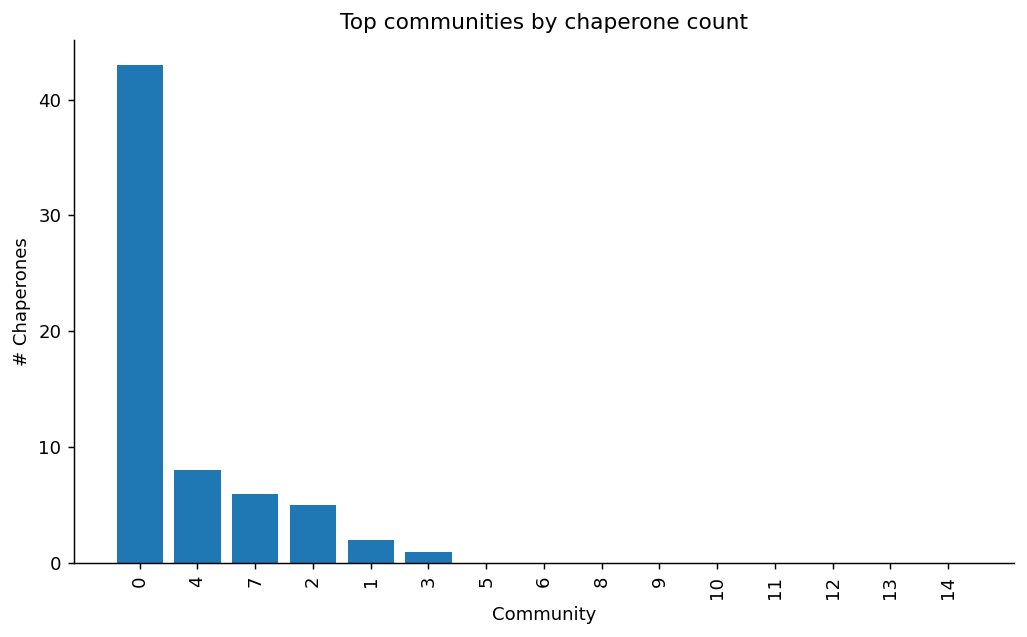

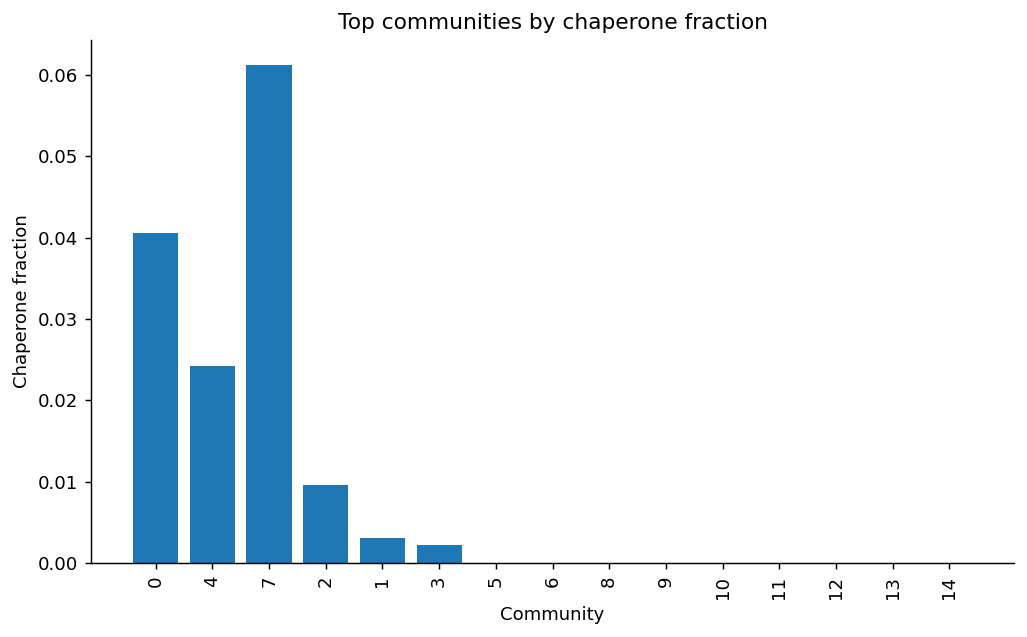

In [18]:
# ============================ CELL: Plots ============================
top_n = 15
plot_df = community_summary.head(top_n)
plt.figure(figsize=(8, 5))
plt.bar(plot_df["community"].astype(str), plot_df["chaperone_count"])
plt.xlabel("Community"); plt.ylabel("# Chaperones")
plt.title("Top communities by chaperone count"); plt.xticks(rotation=90)
plt.tight_layout(); plt.show()

plt.figure(figsize=(8, 5))
plt.bar(plot_df["community"].astype(str), plot_df["chaperone_fraction"])
plt.xlabel("Community"); plt.ylabel("Chaperone fraction")
plt.title("Top communities by chaperone fraction"); plt.xticks(rotation=90)
plt.tight_layout(); plt.show()